# 导数

### 1. 利用微小的差分求导数的过程称为数值微分（numerical differentiation）



In [1]:
import numpy as np
from matplotlib import pyplot as plt

# 设置字体为华文细黑
plt.rcParams['font.sans-serif'] = ['STHeiti']  # macOS 上的华文细黑
plt.rcParams['axes.unicode_minus'] = False  # 解决负号显示问题


def nuerical_diff(f, x):
    """
    数值微分(numerical differentiation)
    """
    h = 1e-4
    return (f(x+h) - f(x-h)) / (2*h)


### 2. 单变量函数求导

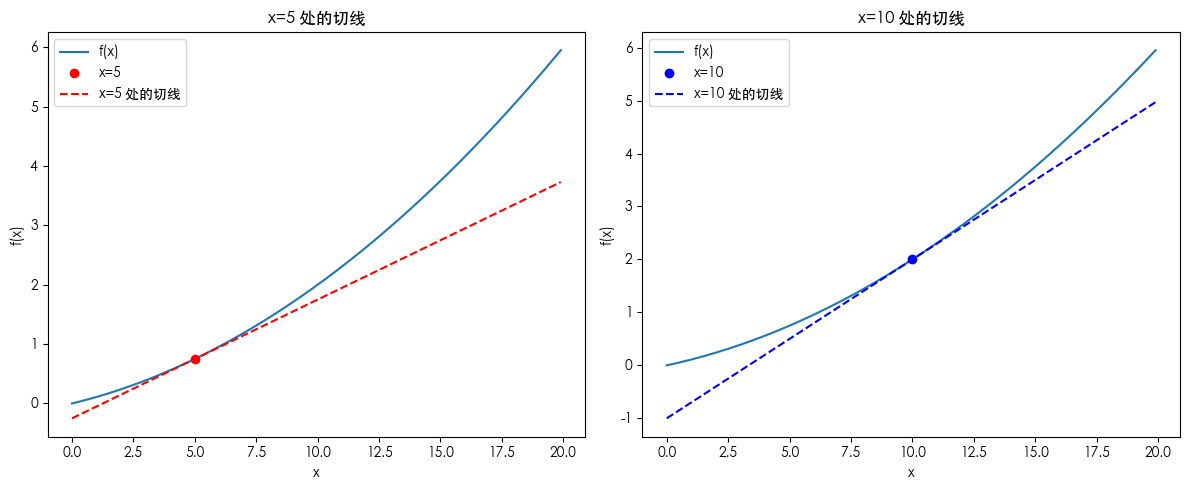

In [2]:
def fun_1(x):
    return 0.01*x**2 + 0.1*x

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
x = np.arange(0.0, 20.0, 0.1)
y = fun_1(x)

# 左图：x=5处的切线
x1 = 5
y1 = fun_1(x1)
y_diff1 = nuerical_diff(fun_1, x1)
axes[0].plot(x, y, label='f(x)')
axes[0].plot(x1, y1, 'ro', label='x=5')
axes[0].plot(x, y1 + y_diff1*(x-x1), 'r--', label='x=5 处的切线')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].legend()
axes[0].set_title('x=5 处的切线')

# 右图：x=10处的切线
x2 = 10
y2 = fun_1(x2)
y_diff2 = nuerical_diff(fun_1, x2)
axes[1].plot(x, y, label='f(x)')
axes[1].plot(x2, y2, 'bo', label='x=10')
axes[1].plot(x, y2 + y_diff2*(x-x2), 'b--', label='x=10 处的切线')
axes[1].set_xlabel('x')
axes[1].set_ylabel('f(x)')
axes[1].legend()
axes[1].set_title('x=10 处的切线')

plt.tight_layout()
plt.show()

### 3. 多变量求导

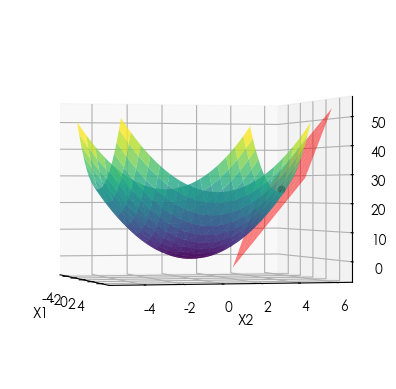

In [6]:
def fun_2(x):
    """
    多变量函数
    """
    return x[0]**2 + x[1]**2

point = np.array([3.0, 4.0])

# 对x1求偏导数
def fun_2_tmp1(x1):
    return x1 ** 2 + point[1] ** 2
partial_diff_x1 = nuerical_diff(fun_2_tmp1, point[0])

# 对x2求偏导数
def fun_2_tmp2(x2):
    return point[0] ** 2 + x2 ** 2
partial_diff_x2 = nuerical_diff(fun_2_tmp2, point[1])

# 计算在点(3, 4)处的函数值
p_y = fun_2(point)

# 定义切平面方程 (基于点斜式)
def tangent_plane(x1, x2, point_x1, point_x2, point_y, grad_x1, grad_x2):
    """计算切平面在 (x1, x2) 处的Z值"""
    return point_y + grad_x1 * (x1 - point_x1) + grad_x2 * (x2 - point_x2)


# --- 绘制曲面 ---
x1 = np.arange(-5, 5, 0.1)
x2 = np.arange(-5, 5, 0.1)

# 绘制3D图
X1, X2 = np.meshgrid(x1, x2)
Y = fun_2([X1, X2])

fig = plt.figure()
ax = fig.add_subplot(111, projection='3d')

# 绘制表面图
ax.plot_surface(X1, X2, Y, cmap='viridis', alpha=0.8, rstride=5, cstride=5)

# --- 绘制切平面 ---
# 定义切平面绘制的范围 (围绕切点)
x1_plane_range = np.linspace(point[0] - 2, point[0] + 2, 10) # 在切点x1周围取一个小的范围
x2_plane_range = np.linspace(point[1] - 2, point[1] + 2, 10) # 在切点x2周围取一个小的范围
X1_plane, X2_plane = np.meshgrid(x1_plane_range, x2_plane_range)

# 计算切平面在选定范围内的Z值
Z_plane = tangent_plane(X1_plane, X2_plane, point[00], point[1], p_y, partial_diff_x1, partial_diff_x2)

# 绘制切平面
ax.plot_surface(X1_plane, X2_plane, Z_plane, color='r', alpha=0.5)

# --- 绘制切点 ---
ax.scatter([point[0]], [point[1]], [p_y], color='k', s=20, label=f'Tangent Point ({point[0]}, {point[1]}, {p_y})')


# 添加标签
ax.set_xlabel('X1')
ax.set_ylabel('X2')
ax.set_zlabel('Y')

# 设置视角
ax.view_init(elev=0, azim=-15) # 可以调整视角以更好地观察

plt.show()



### 梯度

In [16]:

def numerical_gradient(f, x):
    """
    梯度
    """
    h = 1e-4
    grad = np.zeros_like(x)
    
    for idx in range(x.size):
        tmp_val = x[idx]
        x[idx] = tmp_val + h
        fxh1 = f(x)
        
        x[idx] = tmp_val - h
        fxh2 = f(x)
        
        grad[idx] = (fxh1 - fxh2) / (2*h)
        x[idx] = tmp_val
        
    return grad

print(f"梯度为: {numerical_gradient(fun_2, np.array([3.0, 4.0]))}")
print(f"梯度为: {numerical_gradient(fun_2, np.array([0.0, 2.0]))}")
print(f"梯度为: {numerical_gradient(fun_2, np.array([3.0, 0.0]))}")

梯度为: [6. 8.]
梯度为: [0. 4.]
梯度为: [6. 0.]


In [18]:
def gradient_decent(f, init_x, lr=0.01, step_num=100):
    x = init_x
    for i in range(step_num):
        grad = numerical_gradient(f, x)
        x -= lr * grad
    return x

gradient_decent(fun_2, init_x=np.array([3.0, 4.0]), lr=0.1)

array([6.11110793e-10, 8.14814391e-10])